# 060 — Cross-Architecture Delta Comparison (heteroscedastic NLL)

`051_delta_analysis_nll.ipynb` fixes one architecture and compares its signal types (raw delta, structural delta, fixed-window normalized delta, learned z-score) side by side. This notebook flips that: for a single image, it fixes each **signal type** in turn and compares it **across the four NLL architectures** (`unet_nll`, `resunet_nll`, `attention_unet_nll`, `efficientnet_unet_nll`), so architecture differences on the same hidden-detail signal are visible at a glance.

Every comparison figure follows the same layout: the real IR panel first, then one panel per architecture, wrapped at a maximum of 3 columns per row (`scripts.visualization_nll.plot_signal_comparison`).

Architectures without a trained checkpoint at `models/<arch>/best_model.keras` are skipped with a message rather than failing the notebook.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import analyze_delta
from scripts.trainer_nll import load_model_nll
from scripts.visualization_nll import plot_signal_comparison

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Select image and architectures

In [3]:
ARCHS = ["unet_nll", "resunet_nll", "attention_unet_nll", "efficientnet_unet_nll"]
IMAGE_STEM = None  # e.g. "green" — pick a specific image from data/test/rgb/; None = first available

TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"

rgb_paths = sorted(TEST_RGB_DIR.glob("*.jpg")) if TEST_RGB_DIR.exists() else []
test_pairs = [
    (p, TEST_IR_DIR / p.name) for p in rgb_paths if (TEST_IR_DIR / p.name).exists()
]
print(f"Available pairs: {[p.stem for p, _ in test_pairs]}")

Available pairs: ['case', 'green', 'modern', 'total']


## 2. Load real or synthetic (RGB, real IR) pair

If a real test pair is available, uses it for every architecture. Otherwise falls back to a synthetic `(rgb, real_ir)` pair — the same gray-level-shift-vs-structural-change layout used in `050_delta_analysis.ipynb` / `051_delta_analysis_nll.ipynb` — so the notebook remains runnable end to end without test data.

In [4]:
def make_synthetic_pair(size: int = 256, seed: int = 0):
    """Build a synthetic (rgb, real_ir) pair for a dry run."""
    rng = np.random.default_rng(seed)
    x, y = np.meshgrid(np.linspace(0, 6 * np.pi, size), np.linspace(0, 6 * np.pi, size))
    texture = 0.5 + 0.25 * np.sin(x) * np.cos(y)
    real = np.clip(texture + rng.normal(0, 0.02, size=(size, size)), 0.0, 1.0).astype(
        np.float32
    )
    rgb = np.stack([real] * 3, axis=-1)
    return rgb, real


def select_pair(pairs, stem):
    """Return the (rgb, ir) path pair matching stem, or the first pair if None."""
    if stem is None:
        return pairs[0]
    matches = [pair for pair in pairs if pair[0].stem == stem]
    if not matches:
        available = [p.stem for p, _ in pairs]
        raise ValueError(f"IMAGE_STEM='{stem}' not found. Available: {available}")
    return matches[0]


USE_SYNTHETIC_DATA = not test_pairs
print(f"USE_SYNTHETIC_DATA = {USE_SYNTHETIC_DATA}")

if USE_SYNTHETIC_DATA:
    rgb, ir_real = make_synthetic_pair()
    pair_label = "synthetic"
else:
    rgb_path, ir_path = select_pair(test_pairs, IMAGE_STEM)
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir_real = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    pair_label = rgb_path.stem

print(f"Pair: {pair_label} | shape: {ir_real.shape}")

USE_SYNTHETIC_DATA = False
Pair: case | shape: (3237, 2433)


## 3. Run every architecture, collect per-model signals

For each available checkpoint: predict `(mu, sigma)`, run `analyze_delta(ir_real, mu)` for the structural/fixed-window maps, and compute the learned z-score `(ir_real - mu) / sigma`. Missing checkpoints are skipped with a message.

In [5]:
raw_delta_by_arch: dict[str, np.ndarray] = {}
structural_delta_by_arch: dict[str, np.ndarray] = {}
normalized_delta_by_arch: dict[str, np.ndarray] = {}
zscore_by_arch: dict[str, np.ndarray] = {}

for arch in ARCHS:
    try:
        model = load_model_nll(arch, model_dir=settings.MODELS_DIR)
    except (FileNotFoundError, OSError) as exc:
        print(f"Skipping '{arch}': no trained checkpoint found ({exc}).")
        continue

    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    pred_full = model.predict(padded[tf.newaxis, ...], verbose=0)[0]
    h, w = ir_real.shape
    mu = pred_full[:h, :w, 0]
    log_var = pred_full[:h, :w, 1]
    sigma = np.exp(0.5 * log_var)

    result = analyze_delta(ir_real, mu, window_size=11, zone_size=32)

    raw_delta_by_arch[arch] = np.abs(ir_real - mu)
    structural_delta_by_arch[arch] = result.structural_delta
    normalized_delta_by_arch[arch] = result.normalized_delta
    zscore_by_arch[arch] = (ir_real - mu) / (sigma + 1e-8)

    print(f"{arch}: done")

print(f"\nModels compared: {list(raw_delta_by_arch.keys())}")

2026-08-13 10:23:26.434266: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-13 10:23:26.434288: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-13 10:23:26.434294: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-13 10:23:26.434307: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-13 10:23:26.434315: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-08-13 10:23:27.349393: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


unet_nll: done


resunet_nll: done


attention_unet_nll: done


efficientnet_unet_nll: done

Models compared: ['unet_nll', 'resunet_nll', 'attention_unet_nll', 'efficientnet_unet_nll']


## 4. Raw delta — model comparison

`|real_IR - mu|` per architecture. Conflates genuine hidden detail with substrate/acquisition gray-level shifts (`note.md` §1) — the baseline every other signal below tries to improve on.

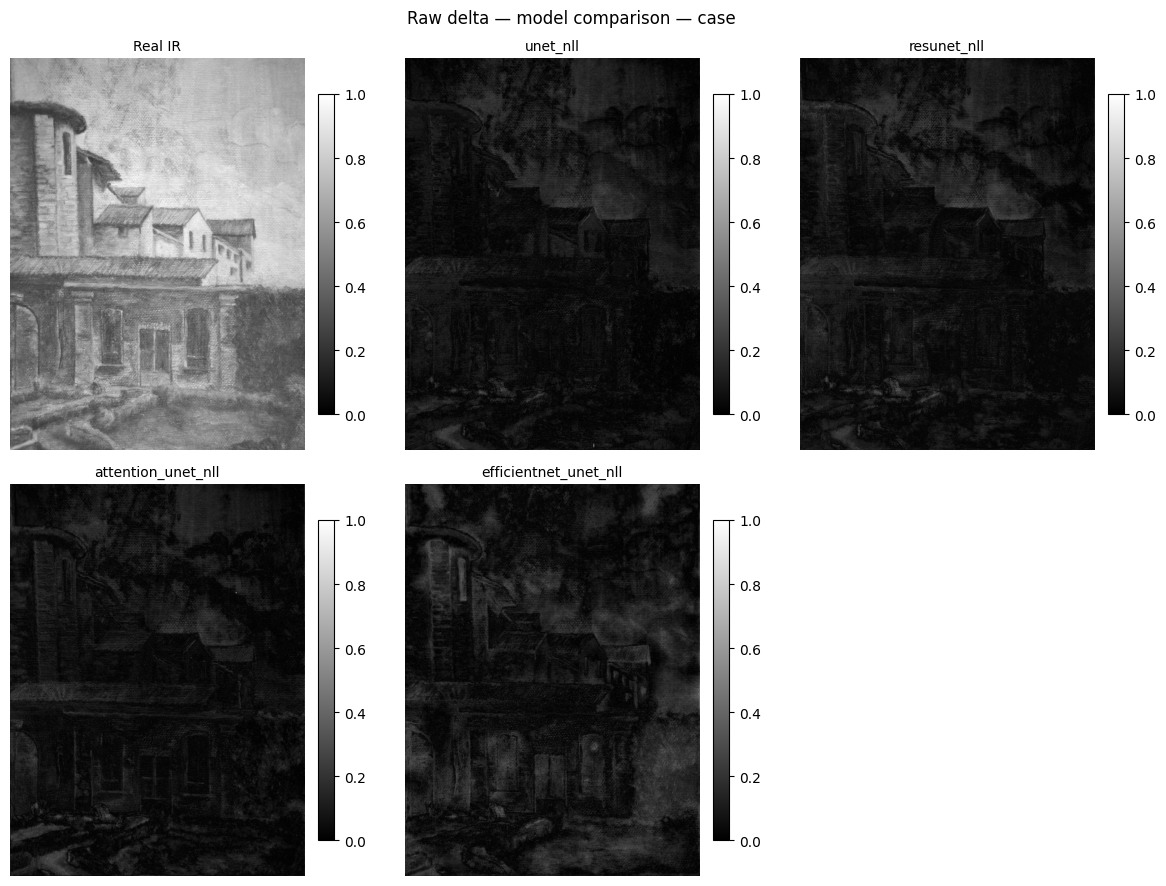

In [6]:
fig = plot_signal_comparison(
    ir_real,
    raw_delta_by_arch,
    title=f"Raw delta — model comparison — {pair_label}",
    vrange=(0.0, 1.0),
)
plt.show()

## 5. Structural delta — model comparison

`1 - local SSIM structure`, insensitive to gray-level shifts, sensitive to genuine structural change (`scripts.delta_analysis`, `note.md` §1).

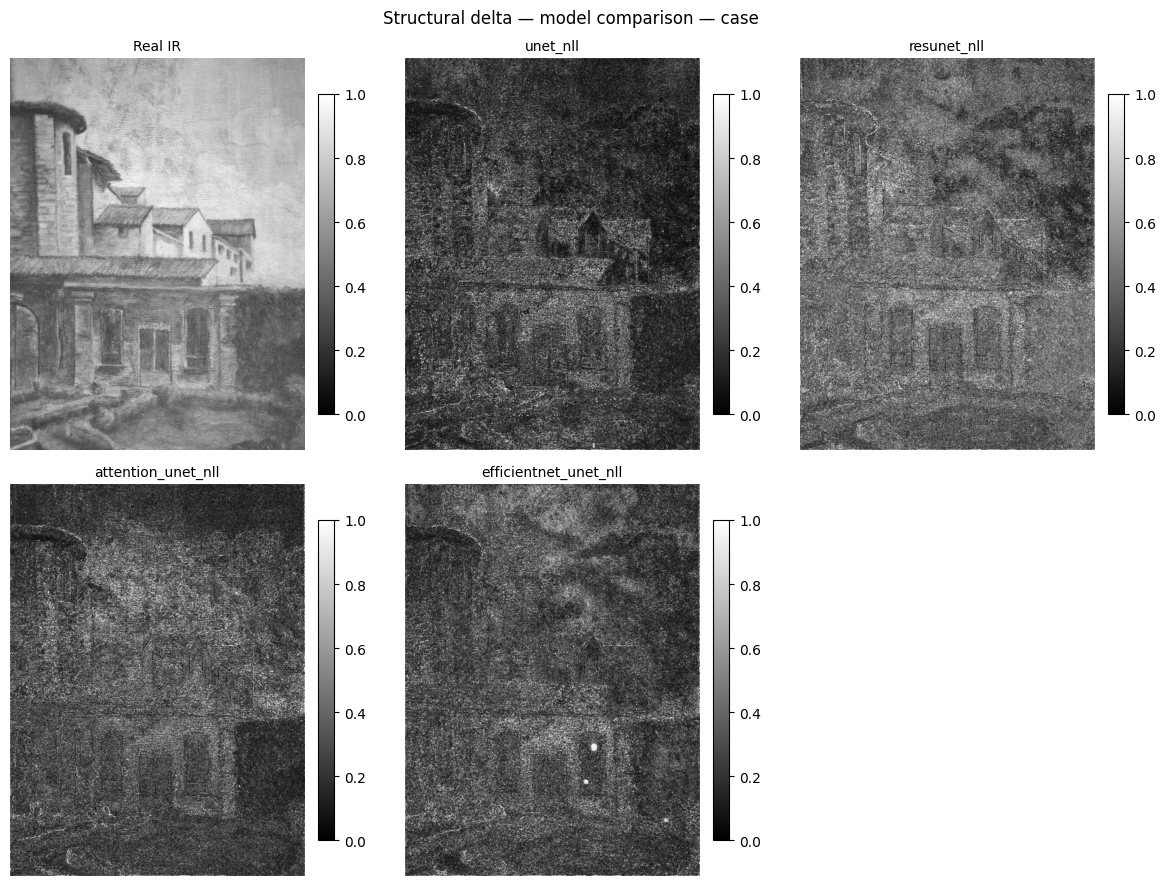

In [7]:
fig = plot_signal_comparison(
    ir_real,
    structural_delta_by_arch,
    title=f"Structural delta — model comparison — {pair_label}",
    vrange=(0.0, 1.0),
)
plt.show()

## 6. Fixed-window normalized delta — model comparison

Per-window z-score delta, spatial-only normalization independent of any model's learned uncertainty (`scripts.delta_analysis`, `note.md` §2). Since this signal is computed from `(ir_real, mu)` alone, differences across architectures here come purely from each model's `mu` prediction.

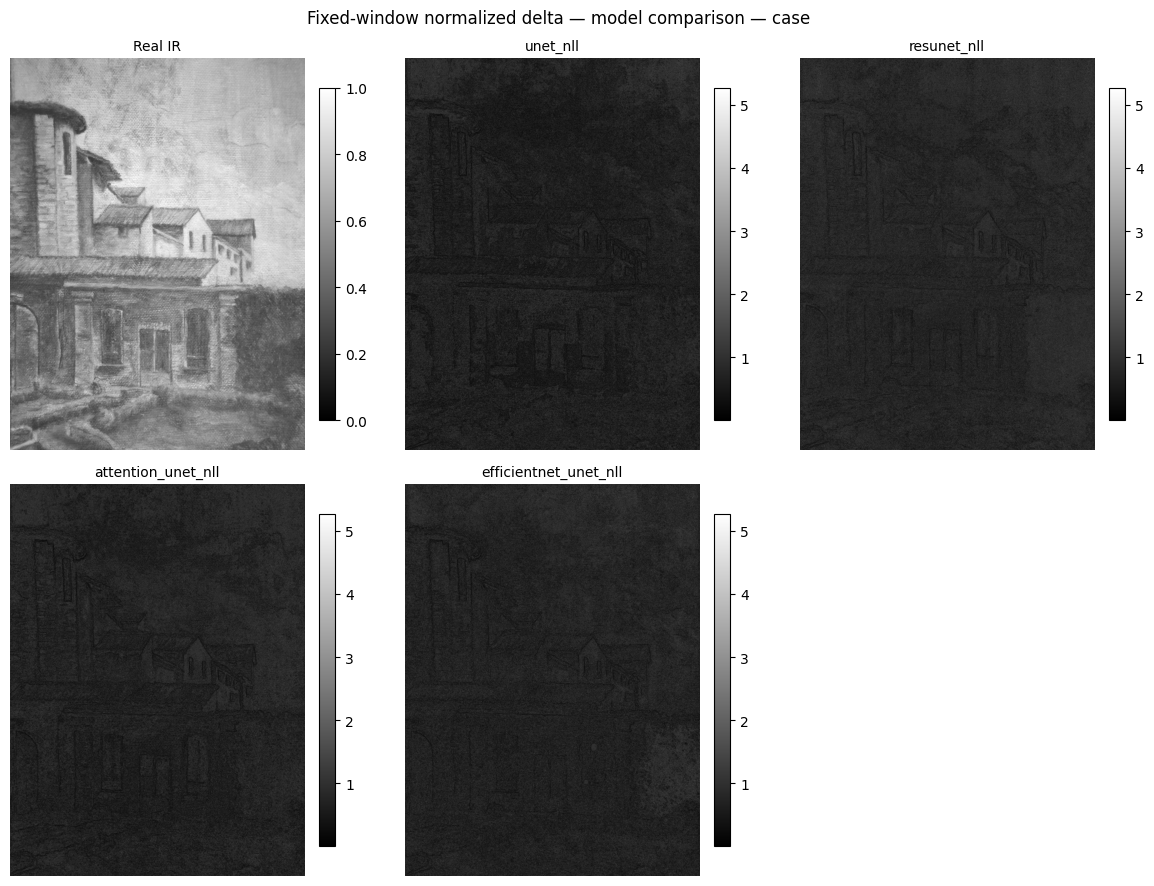

In [8]:
fig = plot_signal_comparison(
    ir_real,
    normalized_delta_by_arch,
    title=f"Fixed-window normalized delta — model comparison — {pair_label}",
)
plt.show()

## 7. Learned z-score — model comparison

`(real_IR - mu) / sigma` — each architecture's own color/context-conditioned normalization (`code-review.md` §7.6, `note.md` "Update" section). Unlike section 6, this one also reflects how confident each architecture is, not just where its `mu` differs from the real IR.

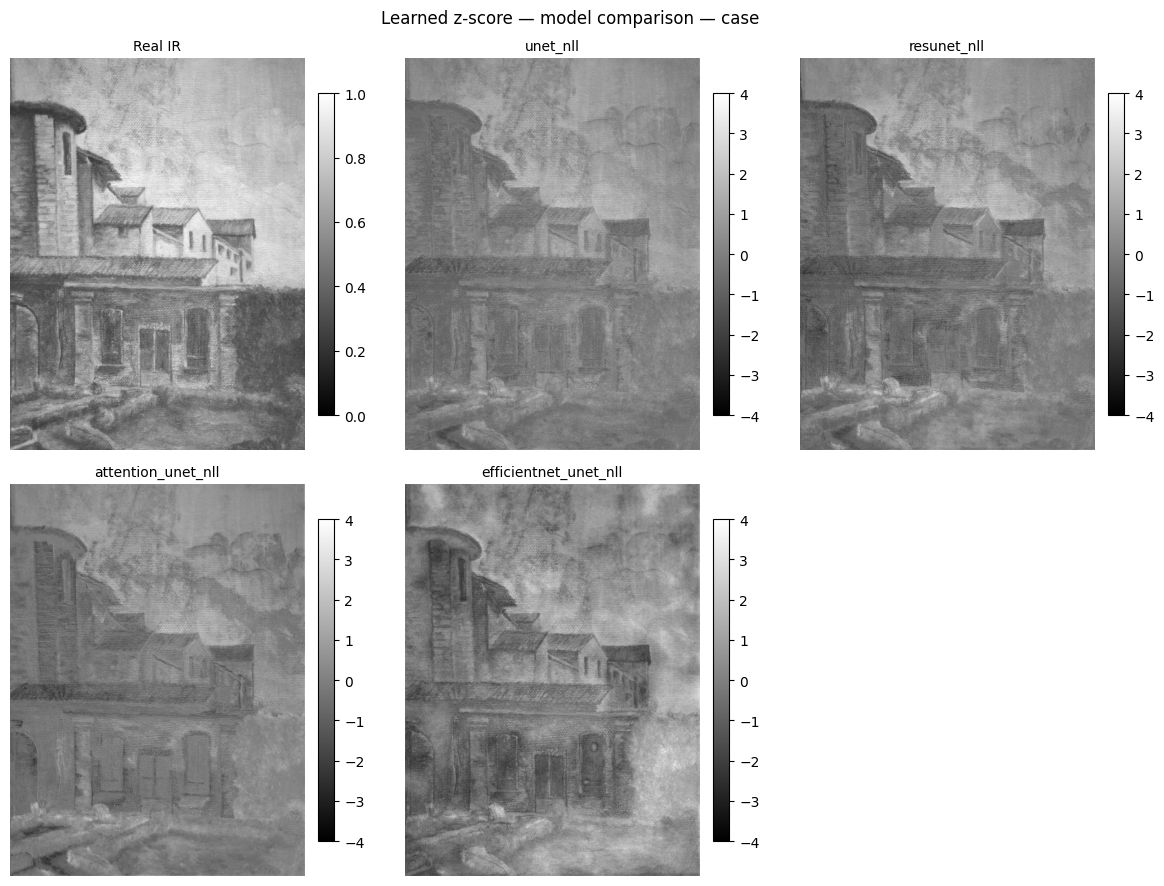

In [9]:
Z_VMAX = 4.0

fig = plot_signal_comparison(
    ir_real,
    zscore_by_arch,
    title=f"Learned z-score — model comparison — {pair_label}",
    vrange=(-Z_VMAX, Z_VMAX),
)
plt.show()